(300, 7)
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
0
Loaded 299 days of date
Original shape 7
PC1 explained: 70.7% of data
PC2 explained: 15.9% of data
PC3 explained: 13.0% of data
First 2 componets capture 86.6% of data
Need 3 components for 95% variance


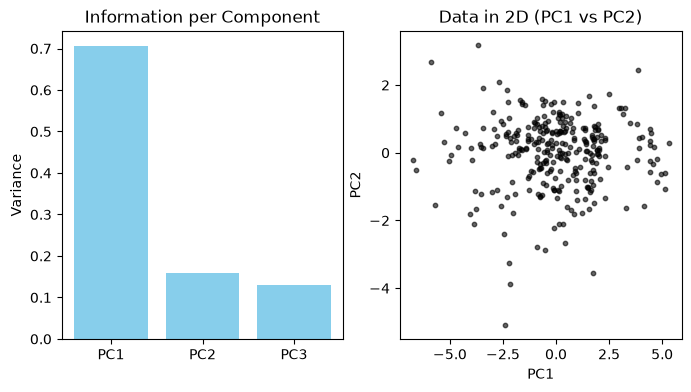

k:2 : scores:0.399
k:3 : scores:0.380
k:4 : scores:0.371
k:5 : scores:0.384
k:6 : scores:0.387
Best K:2


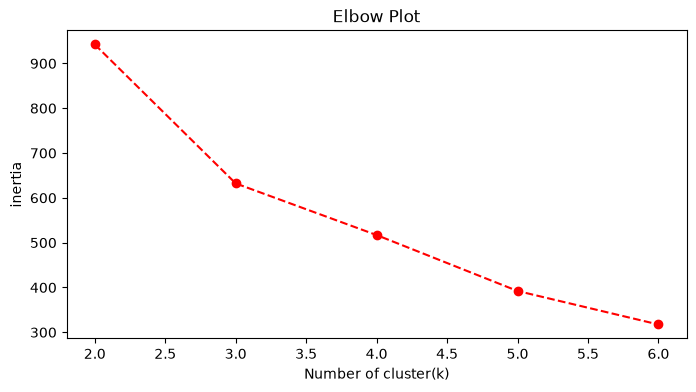

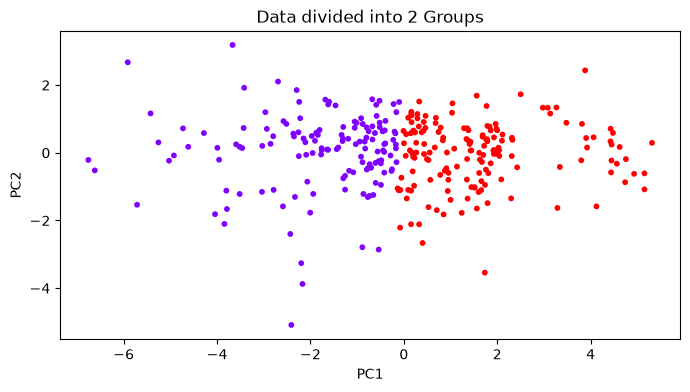

ward: k=2: score:0.397
ward: k=3: score:0.350
ward: k=4: score:0.361
complete: k=2: score:0.438
complete: k=3: score:0.364
complete: k=4: score:0.382
Best:complete, k=4: score:0.382


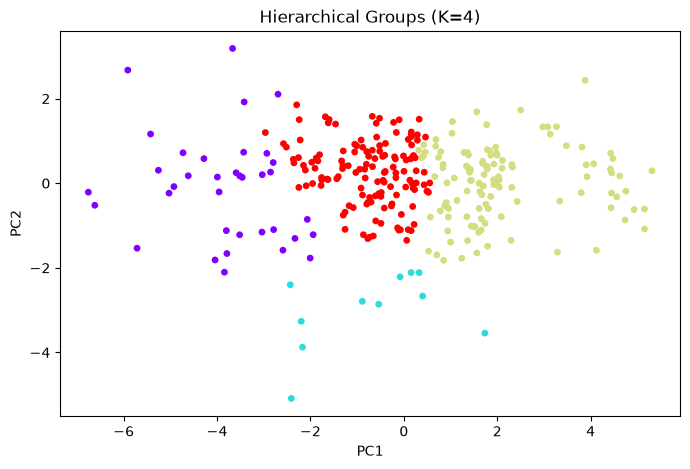

eps=0.5,min=3,cluster=8,Noise=27,Score=-0.046
eps=0.5,min=5,cluster=3,Noise=54,Score=0.231
eps=0.5,min=7,cluster=2,Noise=72,Score=0.276
Best: eps=0.5, min_samples=7


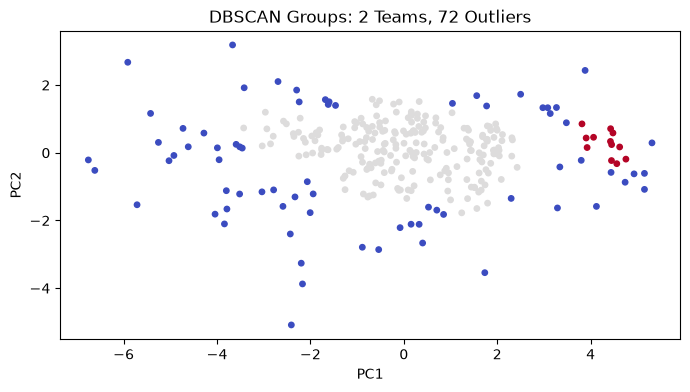

Found 15 unusual days (5.017%)


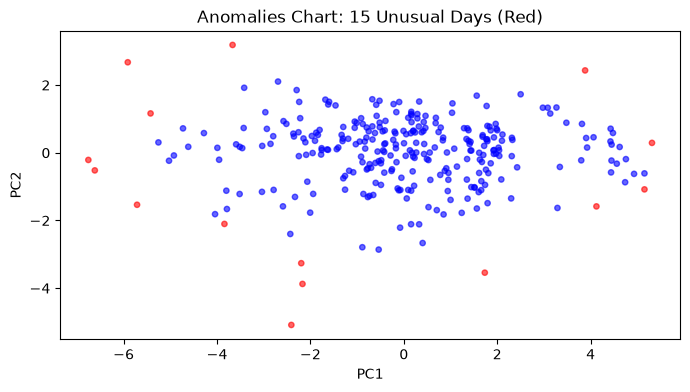

K-Means Score      : 0.399 (4 Groups)
Hierarchical Score : 0.382 (4 Groups)
DBSCAN Score       : 0.539 (2 Groups, 72 Outliers)
Anomalies Found    : 15 Unusual Days

WINNER ALGORITHM: DBSCAN (Score: 0.539)


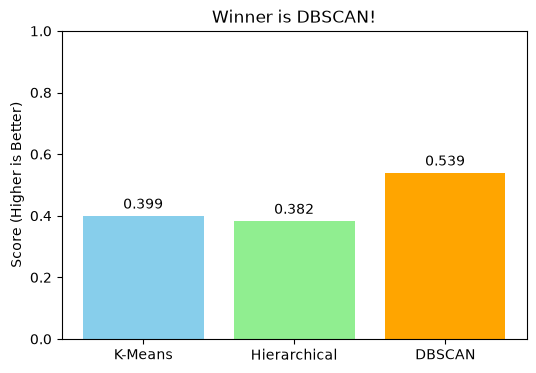

Open:  $7500
Close: $7550
Volume: 1,500,000
K-Means Cluster:     1
DBSCAN Cluster:      0 Normal
Anomaly Status:      Normal
Suggestion: High activity - Consider trading
Open:  $8000
Close: $8100
Volume: 2,000,000
K-Means Cluster:     1
DBSCAN Cluster:      0 Normal
Anomaly Status:      Normal
Suggestion: High activity - Consider trading


(np.int32(1), np.int64(0), np.int64(1))

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data/raw/ftse.csv')
print(df.shape)
print(df.isnull().sum())
print(df.duplicated().sum())

df = df.fillna(method='ffill')
df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)
df.set_index('Date',inplace=True)
df.head()




from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,DBSCAN,AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

df['Return'] = df['Close'].pct_change() * 100
df["Range"] = (df["High"] - df["Low"] / df["Low"] * 100)
df = df.dropna()

feature = ["Open","High","Low","Close","Return","Range","Volume"]

X = StandardScaler().fit_transform(df[feature])

print(f"Loaded {len(df)} days of date")
print(f"Original shape {X.shape[1]}")

#PCA >>>>

pca = PCA()
X_pca = pca.fit_transform(X)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print(f"PC1 explained: {explained[0]*100:.1f}% of data")
print(f"PC2 explained: {explained[1]*100:.1f}% of data")
print(f"PC3 explained: {explained[2]*100:.1f}% of data")
print(f"First 2 componets capture {cumulative[1]*100:.1f}% of data")

n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Need {n_95} components for 95% variance")

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.bar(['PC1','PC2','PC3'],explained[:3],color = 'skyblue')
plt.title('Information per Component')
plt.ylabel('Variance')

plt.subplot(1,2,2)
plt.scatter(X_pca[:,0],X_pca[:,1],color = 'black',alpha=0.6,s=10)
plt.title('Data in 2D (PC1 vs PC2)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


# K-MEANS CLUSTERING (ON PCA DATA)
# Find best K

scores = []
inertia = []

for k in range(2,7):
    kmean_obj = KMeans(n_clusters=k,random_state=42)
    label = kmean_obj.fit_predict(X_pca)
    inertia.append(kmean_obj.inertia_)
    scores.append(silhouette_score(X_pca,label))
    print(f"k:{k} : scores:{scores[-1]:.3f}")

best_k = range(2,7)[scores.index(max(scores))]
print(f"Best K:{best_k}")

kmean = KMeans(n_clusters=best_k,random_state=42)
cluster_label = kmean.fit_predict(X_pca)

plt.figure(figsize=(8,4))
plt.plot(range(2,7),inertia,marker='o',color='red',linestyle = '--')
plt.title('Elbow Plot')
plt.xlabel("Number of cluster(k)")
plt.ylabel("inertia")
plt.show()

plt.figure(figsize=(8,4))
plt.scatter(X_pca[:,0],X_pca[:,1],c=cluster_label,cmap='rainbow',s=10)
plt.title(f'Data divided into {best_k} Groups')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# HIERARCHICAL CLUSTERING (ON PCA DATA)
best_score = -1
best_link,best_k = 'ward',3

for link in ['ward','complete']:
    for k in (2,3,4):
        label = AgglomerativeClustering(n_clusters=k, linkage=link).fit_predict(X_pca)
        score = silhouette_score(X_pca,label)
        print(f"{link}: k={k}: score:{score:.3f}")

    if score > best_score:
        best_score,best_link,best_k = score,link,k

print(f"Best:{best_link}, k={best_k}: score:{best_score:.3f}")

hier = AgglomerativeClustering(n_clusters=best_k,linkage=best_link).fit_predict(X_pca)

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0],X_pca[:,1],c=hier,cmap='rainbow',s=15)
plt.title(f'Hierarchical Groups (K={best_k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# DBSCAN CLUSTERING (ON PCA DATA)
best_score = -1
best_eps,best_min = 1.0,5

for eps in [0.5,1.0,1.5]:
    for min_samp in [3,5,7]:
        labels = DBSCAN(eps=eps, min_samples=min_samp).fit_predict(X_pca)
        n_cluster = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_cluster >= 2:
            score = silhouette_score(X_pca,labels)
            print(f"eps={eps},min={min_samp},cluster={n_cluster},Noise={n_noise},Score={score:.3f}")

            if score > best_score:
                best_score,best_eps,best_min = score,eps,min_samp

print(f"Best: eps={best_eps}, min_samples={best_min}")

dbscan = DBSCAN(eps=best_eps,min_samples=best_min).fit_predict(X_pca)
n_cluster = len(set(dbscan)) - (1 if -1 in dbscan else 0)
n_noise = list(dbscan).count(-1)

plt.figure(figsize=(8,4))
plt.scatter(X_pca[:,0],X_pca[:,1],c=dbscan,cmap='coolwarm',s=15)
plt.title(f'DBSCAN Groups: {n_cluster} Teams, {n_noise} Outliers')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

# Isolation Forest model train karo
iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_model.fit(X_pca)  # PCA data pe train

# Predictions
anomaly_predictions = iso_model.predict(X_pca)
n_anomaly = sum(anomaly_predictions == -1)

print(f"Found {n_anomaly} unusual days ({n_anomaly / len(df)*100 :.3f}%)")

# Visualization
plt.figure(figsize=(8,4))
colors = ['red' if i == -1 else 'blue' for i in anomaly_predictions]
plt.scatter(X_pca[:,0], X_pca[:,1], c=colors, s=15, alpha=0.6)
plt.title(f'Anomalies Chart: {n_anomaly} Unusual Days (Red)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

#Final 
k_score = silhouette_score(X_pca,cluster_label)
h_score = silhouette_score(X_pca,hier)

clear_data = X_pca[dbscan != -1]
clear_label = dbscan[dbscan != -1]

if len(clear_data) > 0:
    d_score = silhouette_score(clear_data,clear_label)

else:
    d_score = 0

scores = [k_score,h_score,d_score]
names = ['K-Means', 'Hierarchical', 'DBSCAN']
winner = names[scores.index(max(scores))]

print(f"K-Means Score      : {k_score:.3f} ({best_k} Groups)")
print(f"Hierarchical Score : {h_score:.3f} ({best_k} Groups)")
print(f"DBSCAN Score       : {d_score:.3f} ({n_cluster} Groups, {n_noise} Outliers)")
print(f"Anomalies Found    : {n_anomaly} Unusual Days")
print(f"\nWINNER ALGORITHM: {winner} (Score: {max(scores):.3f})")

plt.figure(figsize=(6, 4))
bars = plt.bar(['K-Means', 'Hierarchical', 'DBSCAN'], [k_score, h_score, d_score], color=['skyblue', 'lightgreen', 'orange'])
plt.title(f'Winner is {winner}!')
plt.ylabel('Score (Higher is Better)')
plt.ylim(0, 1.0)
plt.bar_label(bars, fmt='%.3f', padding=3)
plt.show()

from scipy.spatial import distance

def analyze_new_market(open_price, high_price, low_price, close_price, volume):
    new_day = pd.DataFrame({
        'Open': [open_price],
        'High': [high_price],
        'Low': [low_price],
        'Close': [close_price],
        'Volume': [volume],
        'Return': [(close_price - open_price) / open_price * 100],
        'Range': [(high_price - low_price) / low_price * 100]
    })
    
    new_scaled = StandardScaler().fit_transform(new_day[feature])
    new_pca = pca_2d.transform(new_scaled)
    
    kmeans_cluster = kmean.predict(new_pca)[0]
    
    distances = distance.cdist(new_pca, X_pca, metric='euclidean')
    nearest_idx = np.argmin(distances)
    dbscan_cluster = dbscan[nearest_idx]
    
    anomaly_status = iso_model.predict(new_pca)[0]
    
   
    print(f"Open:  ${open_price}")
    print(f"Close: ${close_price}")
    print(f"Volume: {volume:,}")

    print(f"K-Means Cluster:     {kmeans_cluster}")
    print(f"DBSCAN Cluster:      {dbscan_cluster} Outlier" if dbscan_cluster == -1 else f"DBSCAN Cluster:      {dbscan_cluster} Normal")
    print(f"Anomaly Status:      Outlier" if anomaly_status == -1 else "Anomaly Status:      Normal")
    
    if dbscan_cluster == -1 or anomaly_status == -1:
        print("Suggestion: Unusual day - Be cautious!")
    elif kmeans_cluster == 1:
        print("Suggestion: High activity - Consider trading")
    else:
        print("Suggestion: Normal day - Follow standard strategy")
    print("="*50)
    
    return kmeans_cluster, dbscan_cluster, anomaly_status

analyze_new_market(7500, 7600, 7450, 7550, 1500000)
analyze_new_market(8000, 8200, 7900, 8100, 2000000)